In [37]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"  # multiple output per jupyter notebook code block
%matplotlib inline

In [38]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 'medium'
plt.rcParams['axes.labelsize'] = 'small'
plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['xtick.labelsize'] = 'small'
plt.rcParams['ytick.labelsize'] = 'small'

### 1.1

In [ ]:
ret = pd.read_excel('damodaran.xlsx', sheet_name='Returns by year', skiprows=1, index_col=0)
ret.mean()

c:\Users\owner\anaconda3\envs\quant312\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


S&P 500 (includes dividends)                       0.118547
US Small cap (bottom decile)                       0.177752
3-month T.Bill                                     0.034149
US T. Bond (10-year)                               0.048224
 Baa Corporate Bond                                0.069019
Real Estate                                        0.043778
Gold*                                              0.073610
Stocks - Bills                                     0.084397
Stocks - Bonds                                     0.070323
Small Cap Premium (S&P 500 minus Bottom Decile)    0.059206
Stocks - Baa Corp Bond                             0.049527
dtype: float64

In [61]:
# Select all the asset classes
returns = ret.iloc[:, :7]

# Use T-Bill as risk-free rate
risk_free_rate = ret.iloc[:, 2]

# Calculate Sharpe Ratio: (mean return - mean risk free rate) / std dev
# For each asset, subtract the risk-free rate from returns, then calculate
excess_returns = returns.subtract(risk_free_rate, axis=0)
empirical = pd.DataFrame(excess_returns.mean() / excess_returns.std(), columns=['Sharpe Ratio'])
cum_returns = (1 + returns).prod() - 1
empirical["Annualized Return"] = (1 + cum_returns) ** (1/len(returns)) - 1

empirical

,Sharpe Ratio,Annualized Return
S&P 500 (includes dividends),0.428332,0.100177
US Small cap (bottom decile),0.372763,0.119818
3-month T.Bill,NaN,0.033716
US T. Bond (10-year),0.184365,0.045346
Baa Corporate Bond,0.442211,0.066296
Real Estate,0.144310,0.041980
Gold*,0.185166,0.056091


In [11]:
returns.corr()

,S&P 500 (includes dividends),US Small cap (bottom decile),3-month T.Bill,US T. Bond (10-year),Baa Corporate Bond,Real Estate,Gold*
S&P 500 (includes dividends),1.000000,0.720687,-0.021436,0.018336,0.404233,0.148432,-0.056180
US Small cap (bottom decile),0.720687,1.000000,-0.151192,-0.101603,0.312088,0.153304,0.011291
3-month T.Bill,-0.021436,-0.151192,1.000000,0.279040,0.119909,0.077605,0.134622
US T. Bond (10-year),0.018336,-0.101603,0.279040,1.000000,0.658236,-0.108288,-0.009333
Baa Corporate Bond,0.404233,0.312088,0.119909,0.658236,1.000000,-0.043207,0.016573
Real Estate,0.148432,0.153304,0.077605,-0.108288,-0.043207,1.000000,0.078504
Gold*,-0.056180,0.011291,0.134622,-0.009333,0.016573,0.078504,1.000000


### 1.2

In [60]:
last_30_years = returns.iloc[-30:]
prev_years = returns.iloc[:-30]

last_30_years.describe()
prev_years.describe()

cumulative_returns_last_30 = (1 + last_30_years).prod() - 1
cumulative_returns_prev = (1 + prev_years).prod() - 1
print("Cumulative Returns (Last 30 Years):")
print(cumulative_returns_last_30)
print("Cumulative Returns (Previous Years):")
print(cumulative_returns_prev)

,S&P 500 (includes dividends),US Small cap (bottom decile),3-month T.Bill,US T. Bond (10-year),Baa Corporate Bond,Real Estate,Gold*
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.117971,0.123887,0.023540,0.042300,0.065319,0.049423,0.098116
std,0.175865,0.259479,0.021201,0.087869,0.068883,0.063001,0.181723
min,-0.365523,-0.446800,0.000300,-0.178282,-0.152281,-0.119952,-0.276142
25%,0.027824,-0.077350,0.001925,0.004541,0.025285,0.027403,-0.005891
50%,0.157516,0.149600,0.018050,0.034258,0.086662,0.054787,0.068941
75%,0.256711,0.223225,0.047050,0.101422,0.107101,0.088893,0.223696
max,0.331037,0.912300,0.060000,0.201013,0.199585,0.188646,0.662158


,S&P 500 (includes dividends),US Small cap (bottom decile),3-month T.Bill,US T. Bond (10-year),Baa Corporate Bond,Real Estate,Gold*
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,0.118800,0.201516,0.038830,0.050837,0.070651,0.041287,0.062798
std,0.202781,0.421269,0.032666,0.075343,0.080071,0.061595,0.228646
min,-0.438375,-0.539400,0.000358,-0.080367,-0.156808,-0.104664,-0.325986
25%,-0.016723,-0.061650,0.010637,0.008986,0.019385,0.008046,-0.004261
50%,0.133102,0.184000,0.031923,0.032822,0.055561,0.029410,0.000000
75%,0.254554,0.427500,0.058298,0.070886,0.117985,0.072650,0.068908
max,0.525633,1.466000,0.140362,0.328145,0.290525,0.241017,1.265487


Cumulative Returns (Last 30 Years):
S&P 500 (includes dividends)    17.710268
US Small cap (bottom decile)    14.193249
3-month T.Bill                   0.997348
US T. Bond (10-year)             2.114997
 Baa Corporate Bond              5.261052
Real Estate                      3.029320
Gold*                           10.213553
dtype: float64
Cumulative Returns (Previous Years):
S&P 500 (includes dividends)     617.381897
US Small cap (bottom decile)    4312.182699
3-month T.Bill                    11.908600
US T. Bond (10-year)              23.775504
 Baa Corporate Bond               85.171482
Real Estate                       12.962697
Gold*                             17.750000
dtype: float64


In [47]:
# Function to calculate portfolio Sharpe ratio
def portfolio_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (portfolio_return - risk_free_rate) / portfolio_std
    return -sharpe  # negative for minimization

# Function to find tangent portfolio
def find_tangent_portfolio(returns, risk_free_rate):
    n_assets = returns.shape[1]
    mean_returns = returns.mean()
    cov_matrix = returns.cov()
    
    # Initial guess: equal weights
    x0 = np.array([1.0/n_assets] * n_assets)
    
    # Constraints: weights sum to 1
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    
    # Bounds: weights between 0 and 1 (long-only)
    bounds = tuple((0, 1) for _ in range(n_assets))
    
    result = minimize(portfolio_sharpe, x0, args=(mean_returns, cov_matrix, risk_free_rate),
                     method='SLSQP', bounds=bounds, constraints=constraints)
    
    return result.x

# Calculate rolling tangent portfolios
lookback = 3

# For last 30 years
last_30_years_weights = []
last_30_years_dates = []

for i in range(lookback, len(last_30_years) + 1):
    window = last_30_years.iloc[i-lookback:i]
    rf_rate = risk_free_rate.iloc[i-lookback:i].mean()
    weights = find_tangent_portfolio(window, rf_rate)
    last_30_years_weights.append(weights)
    last_30_years_dates.append(last_30_years.index[i-1])

# For previous years
prev_years_weights = []
prev_years_dates = []

for i in range(lookback, len(prev_years) + 1):
    window = prev_years.iloc[i-lookback:i]
    rf_rate = risk_free_rate.iloc[i-lookback:i].mean()
    weights = find_tangent_portfolio(window, rf_rate)
    prev_years_weights.append(weights)
    prev_years_dates.append(prev_years.index[i-1])

# Create dataframes for results
tangent_portfolio_last_30 = pd.DataFrame(last_30_years_weights, 
                                         index=last_30_years_dates, 
                                         columns=returns.columns)
tangent_portfolio_prev = pd.DataFrame(prev_years_weights, 
                                      index=prev_years_dates, 
                                      columns=returns.columns)

In [ ]:
print("Mean Tangent Portfolio Weights (Last 30 Years):")
print(tangent_portfolio_last_30.mean())
print("Mean Tangent Portfolio Weights (Previous Years):")
print(tangent_portfolio_prev.mean())

Tangent Portfolio Weights (Last 30 Years):
S&P 500 (includes dividends)    0.121474
US Small cap (bottom decile)    0.050442
3-month T.Bill                  0.183570
US T. Bond (10-year)            0.124856
 Baa Corporate Bond             0.099762
Real Estate                     0.345141
Gold*                           0.075217
dtype: float64
Tangent Portfolio Weights (Previous Years):
S&P 500 (includes dividends)    0.059540
US Small cap (bottom decile)    0.053451
3-month T.Bill                  0.352413
US T. Bond (10-year)            0.102672
 Baa Corporate Bond             0.193819
Real Estate                     0.166255
Gold*                           0.072076
dtype: float64


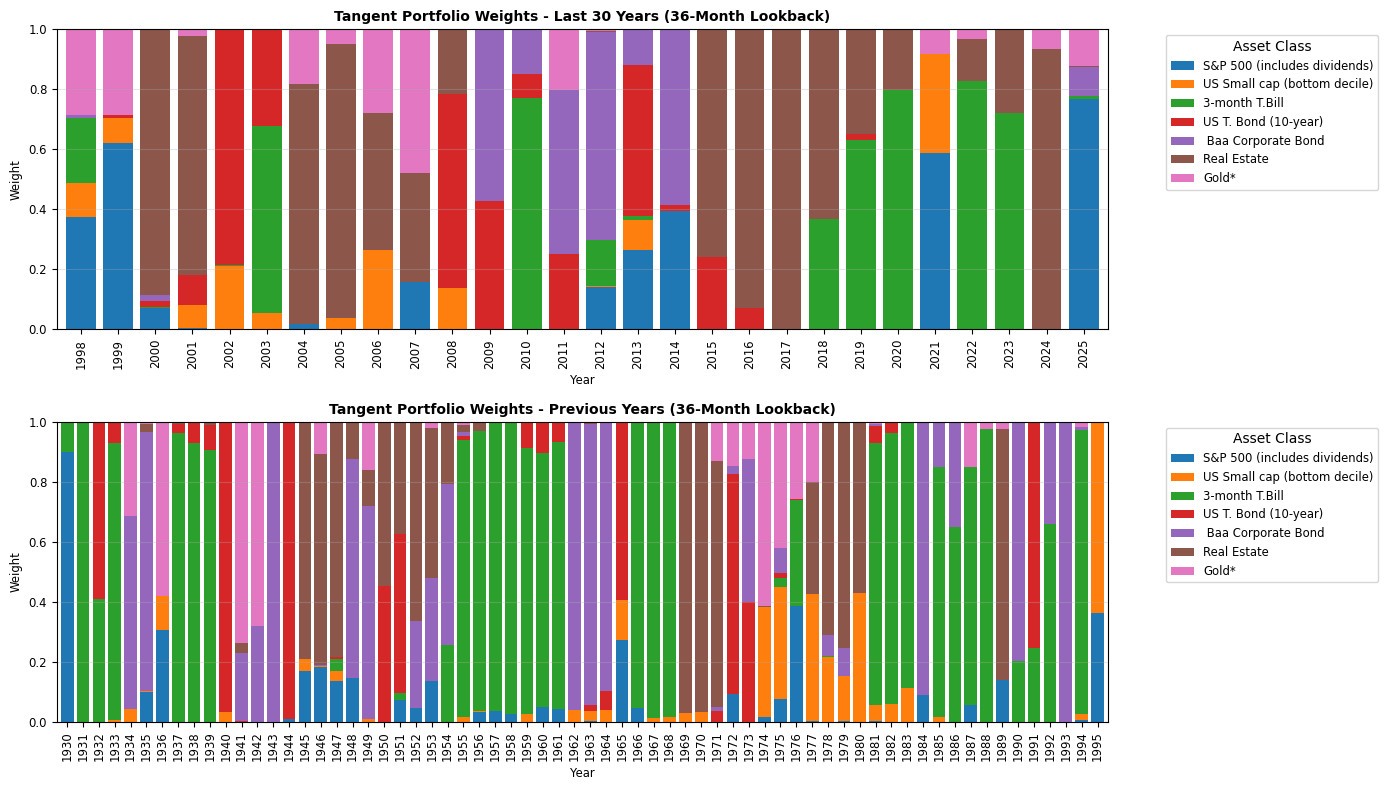

In [48]:
# Plot tangent portfolio weights for last 30 years
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Last 30 years
tangent_portfolio_last_30.plot(kind='bar', stacked=True, ax=ax1, width=0.8)
ax1.set_title('Tangent Portfolio Weights - Last 30 Years (36-Month Lookback)', fontsize='medium', fontweight='bold')
ax1.set_ylabel('Weight', fontsize='small')
ax1.set_xlabel('Year', fontsize='small')
ax1.legend(title='Asset Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# Previous years
tangent_portfolio_prev.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
ax2.set_title('Tangent Portfolio Weights - Previous Years (36-Month Lookback)', fontsize='medium', fontweight='bold')
ax2.set_ylabel('Weight', fontsize='small')
ax2.set_xlabel('Year', fontsize='small')
ax2.legend(title='Asset Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show();

In [57]:
# Calculate portfolio return series for the tangent portfolios (weights * returns)
pf_returns_last_30 = (tangent_portfolio_last_30 * last_30_years.reindex(tangent_portfolio_last_30.index)).sum(axis=1)
pf_returns_prev = (tangent_portfolio_prev * prev_years.reindex(tangent_portfolio_prev.index)).sum(axis=1)

# Cumulative returns
cum_pf_last_30 = (1 + pf_returns_last_30).cumprod() - 1
cum_pf_prev = (1 + pf_returns_prev).cumprod() - 1

# Summary
annualized_return_last_30 = (cum_pf_last_30.iloc[-1] + 1) ** (1 / len(pf_returns_last_30)) - 1
annualized_return_prev = (cum_pf_prev.iloc[-1] + 1) ** (1 / len(pf_returns_prev)) - 1
print("Annualized Return (Last 30 Years):", annualized_return_last_30)
print("Annualized Return (Previous Years):", annualized_return_prev)

Annualized Return (Last 30 Years): 0.08827108983260845
Annualized Return (Previous Years): 0.08254273431099612


### 1.6

In [64]:
mpf = pd.read_csv('mpf_category_annual_returns.csv', index_col=0)
mpf_cum_ret = (1 + mpf).prod() - 1
mpf_cum_ret["hk_GlobalEquityLargeCap"] - mpf_cum_ret["hk_GreaterChinaEquity"]

np.float64(0.11999858823689147)

In [72]:
from scipy.optimize import brentq

def npv(rate, cash_flows):
    """Calculate Net Present Value given a discount rate"""
    return sum([cf / (1 + rate)**i for i, cf in enumerate(cash_flows)])

def irr_with_annual_contrib(returns, contrib=1.0, growth=0.00):
    """
    returns : pd.Series of annual returns
    contrib : amount put in at the *start* of each year
    growth  : annual growth rate of contribution (default 3%)
    """
    fv = 0.0
    for r in returns:
        fv = (fv + contrib) * (1 + r)      # deposit then earn
        contrib *= 1 + growth  # increase contribution by growth per year
    # cash‑flows: negative contributions for years 0…n‑1, final positive value
    flows = [-contrib] * len(returns) + [fv]

    # Find IRR where NPV = 0
    try:
        irr = brentq(lambda r: npv(r, flows), -0.99, 1.0)
        return irr
    except ValueError:
        print("Could not find IRR in range")
        return np.nan

irr_hk = irr_with_annual_contrib(mpf["hk_GreaterChinaEquity"])
irr_global   = irr_with_annual_contrib(mpf["hk_GlobalEquityLargeCap"])

print("IRR:")
print(f" Greater China Equity → {irr_hk:.2%}")
print(f" Global Equity → {irr_global:.2%}")

IRR:
 Greater China Equity → 2.78%
 Global Equity → 6.00%
